In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
fake = pd.read_csv("Fake.csv")
true = pd.read_csv("True.csv")
fake.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [3]:
true.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [4]:
fake["label"] = 0
true["label"] = 1


In [5]:
df = pd.concat([fake, true])
df = df.sample(frac=1).reset_index(drop=True)

In [6]:
df.duplicated().sum()

np.int64(209)

In [7]:
df = df.drop_duplicates()

In [8]:
df = df[["label", "text"]]
df.head()

,label,text
0,0,Leading Republican presidential candidate Dona...
1,1,OSLO (Reuters) - The Russian helicopter that w...
2,0,Yeah putting the federal government in charge ...
3,0,The owner of a masonry business in Colorado is...
4,0,"While Charlotte, North Carolina faces a state ..."


In [9]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    df["text"], df["label"], test_size=0.30, random_state=32)

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer
t = TfidfVectorizer(stop_words="english", max_features=3000)
x_train = t.fit_transform(x_train)
x_test = t.transform(x_test)

In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [12]:
model = Sequential([
    Dense(256, activation="relu", input_shape=(x_train.shape[1],)),
    Dropout(0.3),
    Dense(128, activation="relu"),
    Dropout(0.3),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(32, activation="relu"),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])

C:\Users\agraw\Downloads\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
model.compile(
    optimizer="adam", 
    loss='binary_crossentropy',
    metrics=["accuracy"]
)

In [14]:
history = model.fit(x_train, y_train, epochs=10, batch_size=64, validation_split=0.2)

Epoch 1/10
392/392 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9496 - loss: 0.1376 - val_accuracy: 0.9839 - val_loss: 0.0521
Epoch 2/10
392/392 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9911 - loss: 0.0297 - val_accuracy: 0.9840 - val_loss: 0.0455
Epoch 3/10
392/392 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9960 - loss: 0.0142 - val_accuracy: 0.9839 - val_loss: 0.0559
Epoch 4/10
392/392 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9974 - loss: 0.0081 - val_accuracy: 0.9861 - val_loss: 0.0651
Epoch 5/10
392/392 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9984 - loss: 0.0051 - val_accuracy: 0.9850 - val_loss: 0.0686
Epoch 6/10
392/392 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9990 - loss: 0.0032 - val_accuracy: 0.9819 - val_loss: 0.1018
Epoch 7/10
392/392 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9991 - loss: 0.0037 - val_accuracy: 0.9848 - val_loss: 0.0672
Epoch 8/10
392/392 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9987 - loss: 0.0037 - val_accuracy: 0.

In [15]:
predictions = model.predict(x_test)
prediction_class = (predictions > 0.5).astype(int)

419/419 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [16]:
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test, prediction_class))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      7044
           1       0.98      0.99      0.99      6363

    accuracy                           0.99     13407
   macro avg       0.99      0.99      0.99     13407
weighted avg       0.99      0.99      0.99     13407



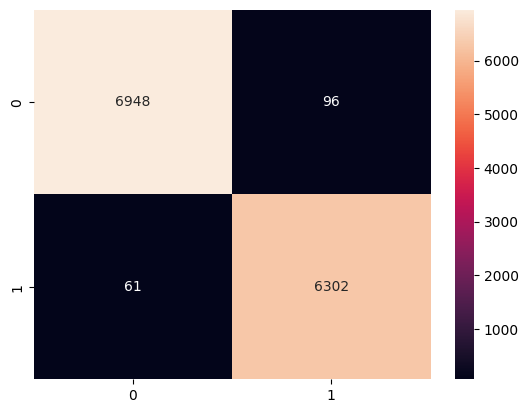

In [17]:
cm = confusion_matrix(y_test, prediction_class)
sns.heatmap(cm, annot=True, fmt='d')
plt.show()

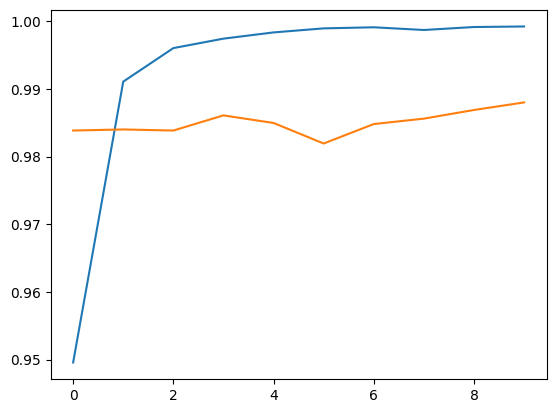

In [18]:
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.show()

In [19]:
def predict_news(text):
    sample = t.transform([text])
    result = model.predict(sample)
    return "True" if result[0][0] > 0.5 else "Fake"


In [20]:
print(predict_news('donald trump is dead'))
print(predict_news('Donald Trump is President.'))
print(predict_news("fast food are non healthy"))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
Fake
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
True
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
Fake


In [21]:
def check_raw_score(text):
    sample = t.transform([text])
    result = model.predict(sample)
    print(f"Raw score for '{text}': {result[0][0]}")

check_raw_score('donald trump is dead')
check_raw_score('donald trump is president.')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
Raw score for 'donald trump is dead': 2.427723848086316e-05
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
Raw score for 'donald trump is president.': 0.9886732697486877
